# Phase 4: Exploratory Data Analysis (Housing)

**Objective:** To identify the drivers of property value.

Our target variable is `price`. We aim to understand how physical attributes (area, bedrooms, etc.) and amenities (air conditioning, parking) influence the market value of a home.

### 1. Environment Setup
We load our custom configuration and data ingestion tools. We use `autoreload` to ensure that any changes we make to our `src/` modules are instantly reflected in this notebook without needing to restart the kernel.

In [32]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import pandas as pd
import src.visualization.plots as plots
from src.visualization.plots import (
    set_journalism_style,
    plot_histogram,
    plot_bar_chart,
    plot_box,
    plot_categorical_target_rate,
    plot_correlation_heatmap,
)

set_journalism_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
df = pd.read_csv(Path.cwd().parent.parent / "datasets" / "processed" / "housing_cleaned.csv")
print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (545, 13)


### 1. Univariate Analysis
**Goal:** Understand the distribution of house prices and key physical attributes.

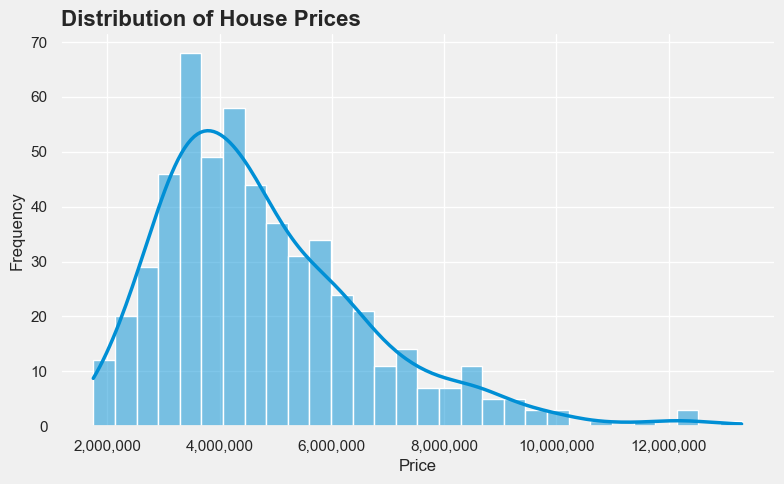

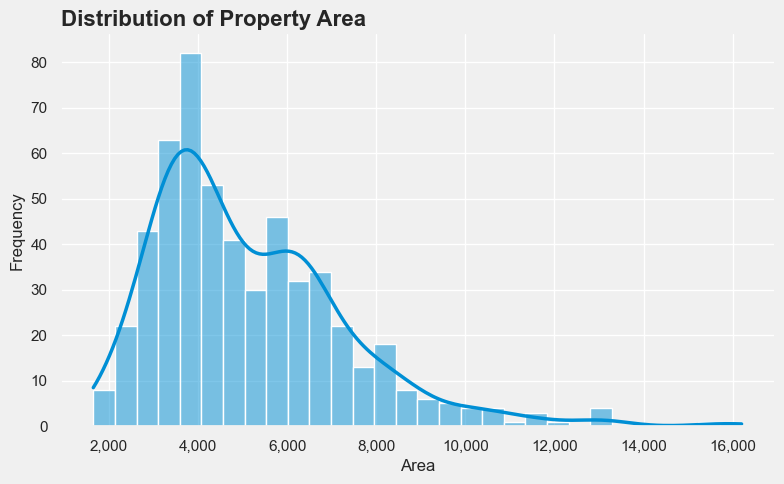

In [34]:
# Price Distribution
plot_histogram(df, 'price', "Distribution of House Prices")

# Area Distribution
plot_histogram(df, 'area', "Distribution of Property Area")

### 2. Bivariate Analysis
**Goal:** Investigate how amenities and structure influence the target (`price`).

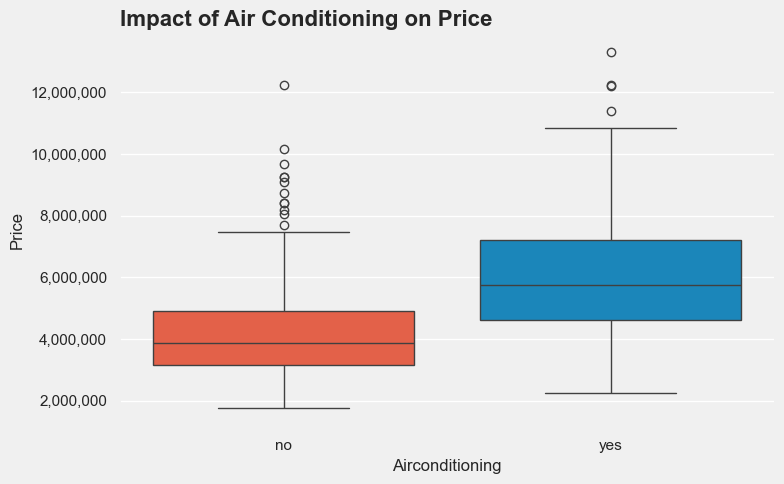

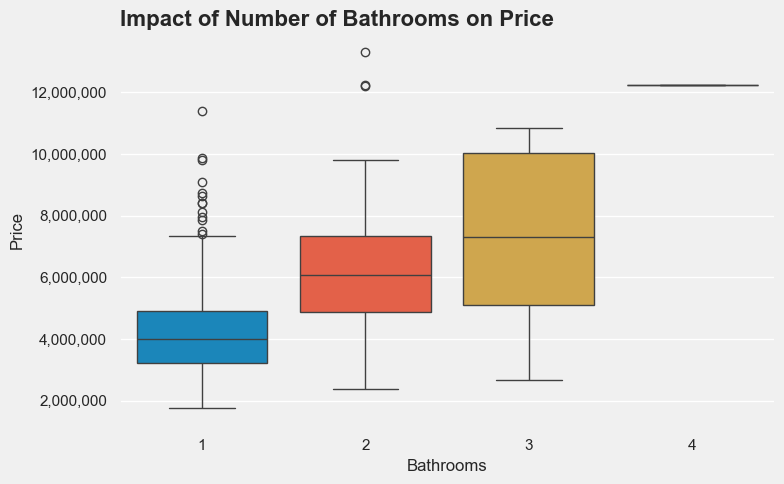

In [35]:
# Relationship between Air Conditioning and Price
plot_box(df, 'airconditioning', 'price', "Impact of Air Conditioning on Price")

# Relationship between Bathrooms and Price
plot_box(df, 'bathrooms', 'price', "Impact of Number of Bathrooms on Price")

### 3. Correlation Analysis
**Goal:** Quantify the linear relationship between numerical features.

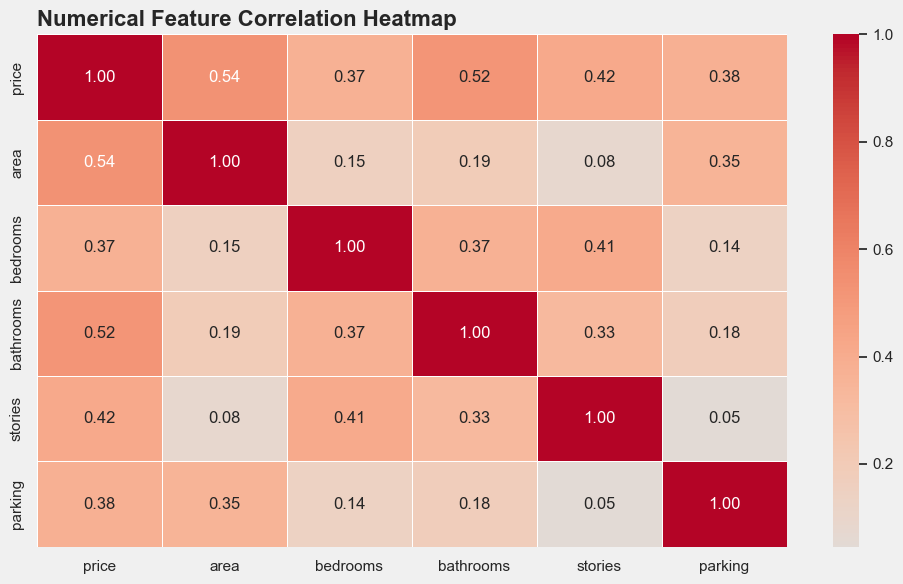

In [36]:
plot_correlation_heatmap(df, "Numerical Feature Correlation Heatmap")

### Phase 4 Conclusion: Key Insights
1. **Univariate Analysis:** Both `Price` and `Area` follow a unimodal, heavily right-skewed distribution. The majority of properties cater to the lower-to-middle market, with a long tail of high-priced outlier properties.
2. **Bivariate Analysis (The Signals):**
   - **Air Conditioning:** Properties with AC have a distinctly higher median price and a much wider upper spread. The middle 50% (the box) barely overlaps with non-AC homes.
   - **Bathrooms:** There is a stark, non-overlapping jump in price from 1 to 2 bathrooms. The 4-bathroom category appears as a flat line outlier due to a very low sample size.
3. **Correlation:** `Area` (0.54) and `Bathrooms` (0.52) have the highest positive linear correlation with `Price`.
4. **Actionable Takeaway:** Both continuous (`Area`) and categorical (`AC`, `Bathrooms`) features drive value. The extreme right-skewness means we must handle outliers and scale features carefully.